## Linear algebra

This notebook tries to summarize a common semester of linear algebra in a visual way

The main order is based on the ook *Linear Algebra Done Right*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Crear la leyenda para el plano a mano
from matplotlib.patches import Patch

### Vector spaces

We will define a vector space to be a set V with an addition and a scalar multiplication on V that satisfy the properties in the paragraph above.

Some definitions:

#### Addition
An addition on a set V is a function that assigns an element $u + v \in V$ to each pair of elements $u, v \in V$

#### Scalar multiplication
An scalar multiplication on a set V is a function that assigns an element $\lambda v \in V$ to each $\lambda \in R$ and each $v \in V$

#### Vector space

A vector space is a set V along with an addition of V and scalar multiplication on V such that the following properties hold

 - Communativity: *u + v = v + u*
 - Associativity: *(u + v) + w = u + (v + w)*
 - Additive identity: *v + 0 = v*
 - Additive inverse: *Exists w such that v + w = 0*
 - Multiplicative identity: *1v = v*
 - Distributive properties: *a(u + v) = au + av*

Examples of vector spaces: 

We could start with $\mathbb{R}$

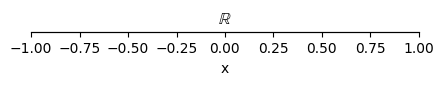

In [ ]:
fig, ax = plt.subplots(figsize=(5, 1e-5))
ax.plot()
ax.grid(True)
ax.set_xlim(-1, 1)
ax.set_title('$\mathbb{R}$')
ax.set_xlabel('R')
ax.set_yticks([])
plt.show()

Another useful vector space is $\mathbb{R}^2$

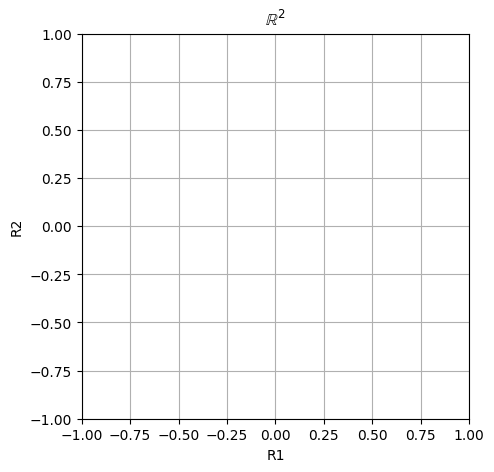

In [36]:
fig, ax, = plt.subplots(figsize=(5,5))
ax.plot()
ax.grid(True)
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_title('$\mathbb{R}^2$')
ax.set_xlabel('R1')
ax.set_ylabel('R2')
plt.show()

And $\mathbb{R}^3$

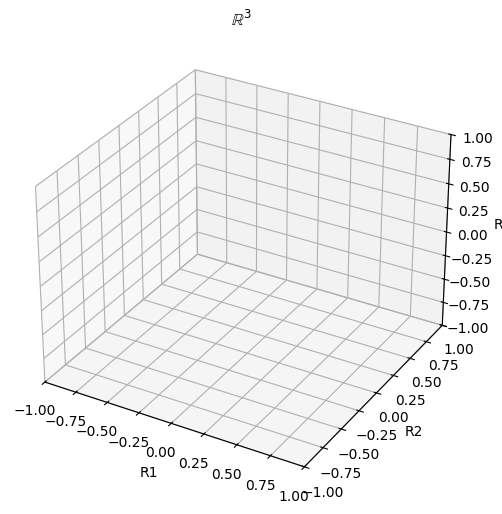

In [35]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot([0], [0], [0])
ax.grid(True)
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
ax.set_title('$\mathbb{R}^3$')
ax.set_xlabel('R1')
ax.set_ylabel('R2')
ax.set_zlabel('R3')
plt.show()

#### Vector
Elements of a vector space are called vectors or points

We can show how an addition and a scalar multiplication looks like

In [108]:
#Let's define some functions to plot vectors and configurations

def r2_config(ax, title='$\mathbb{R}^2$'):
    ax.grid(True)
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)
    ax.set_title(title)
    ax.set_xlabel('R1')
    ax.set_ylabel('R2')
    return ax
def plot_vector(ax, vector, color='b'):
    ax.arrow(0, 0, vector[0], vector[1],
        head_width=0.05, head_length=0.08,
        fc=color, ec=color, length_includes_head=True)
    ax.text(vector[0], vector[1], f'({round(vector[0], 2)}, {round(vector[1], 2)})', fontsize=12, ha='left', va='bottom', color=color)
    return ax

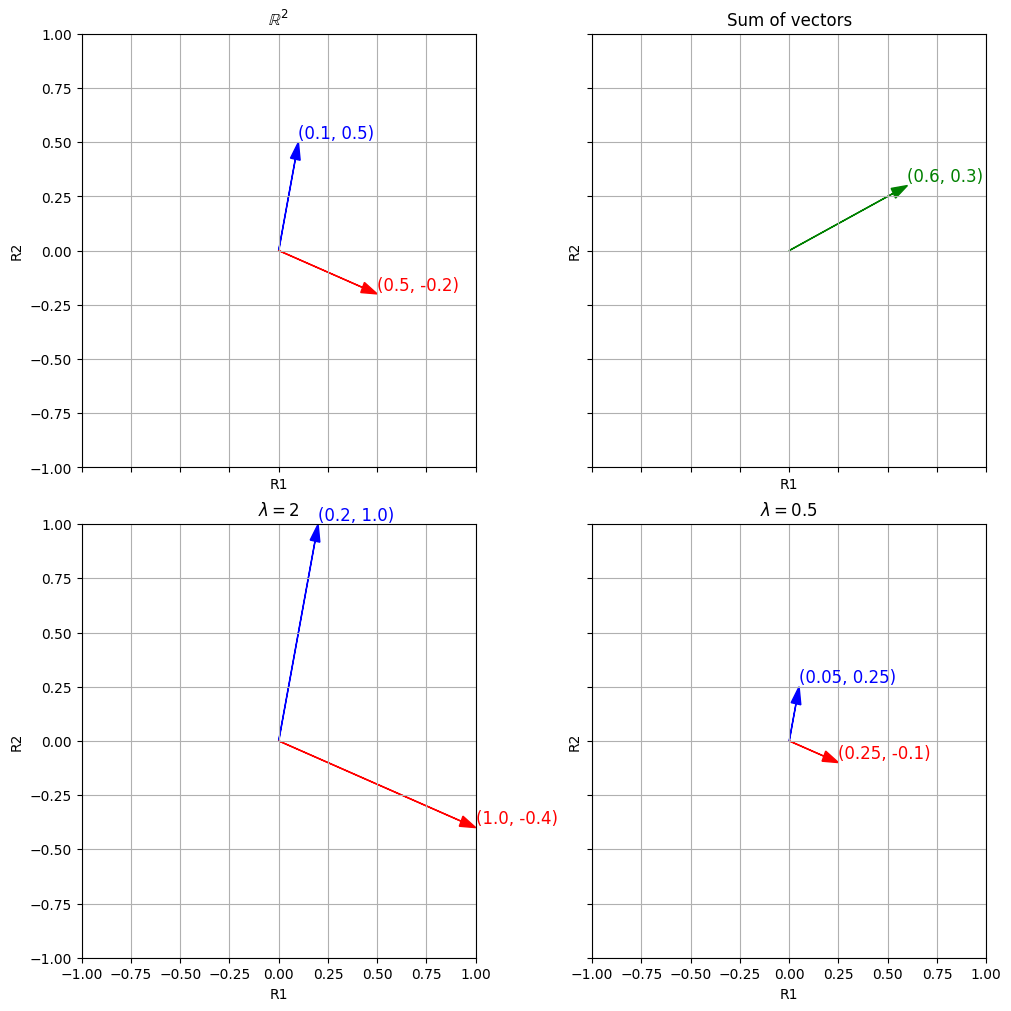

In [111]:
#Our vectors
vectors = np.array([
    [0.1, 0.5],
    [0.5, -0.2]
])
colors = ["b", "r"]


fig, ax = plt.subplots(2, 2, figsize=(10, 10), sharey=True, sharex=True, constrained_layout=True)

for vector, color in zip(vectors, colors):
    plot_vector(ax[0, 0], vector, color)
ax[0, 0] = r2_config(ax[0, 0])

sum_vector = vectors.sum(axis=0)
plot_vector(ax[0, 1], sum_vector, "g")
ax[0, 1] = r2_config(ax[0, 1], title='Sum of vectors')

lam = 2
lambda_vector = lam * vectors
for vector, color in zip(lambda_vector, colors):
    plot_vector(ax[1, 0], vector, color)
ax[1, 0] = r2_config(ax[1, 0], title=f'$\lambda = {lam}$')


lam = 0.5
lambda_vector = lam * vectors
for vector, color in zip(lambda_vector, colors):
    plot_vector(ax[1, 1], vector, color)
ax[1, 1] = r2_config(ax[1, 1], title=f'$\lambda = {lam}$')

plt.show()

Additive identity. A vector space has a unique additive identity. It is denoted by the vector $0$

In [120]:
vector = np.array([1, 0, 0.5])
identity = np.array([0, 0, 0])
display(vector)
display(identity)
display(vector + identity) #Keeps the same vector

array([1. , 0. , 0.5])

array([0, 0, 0])

array([1. , 0. , 0.5])

Additive inverse. Every element in a vector space has a unique additive inverse

In [131]:
vector = np.array([1, 0, 0.5])
inverse = -vector #The inverse of a vector is the vector
                  #with the same magnitude but opposite direction
display(vector)
display(inverse)
display(vector + inverse) #The result is zero.

array([1. , 0. , 0.5])

array([-1. , -0. , -0.5])

array([0., 0., 0.])

The number 0 times a vector

$0v = 0$ for every $v \in V$

In [124]:
vector = np.array([1, 0, 0.5])
zero = np.array([0, 0, 0])
display(vector)
display(zero)
display(vector * zero) #The result is zero

array([1. , 0. , 0.5])

array([0, 0, 0])

array([0., 0., 0.])

## Subspaces

A subset U of V is called a subspace of V if U is also a vector space with the same additive identity, addition, and scalar multiplication as on V.

Conditions:

 - Additive identity
 - Closed under addition
 - Closed under scalar multiplication

For example, $\mathbb{R}^2$ is a subspace of $\mathbb{R}^3$.

The elements of $R2$ are closed under addition and scalar multiplication. If we perform the operations, they remain in the same subspace.

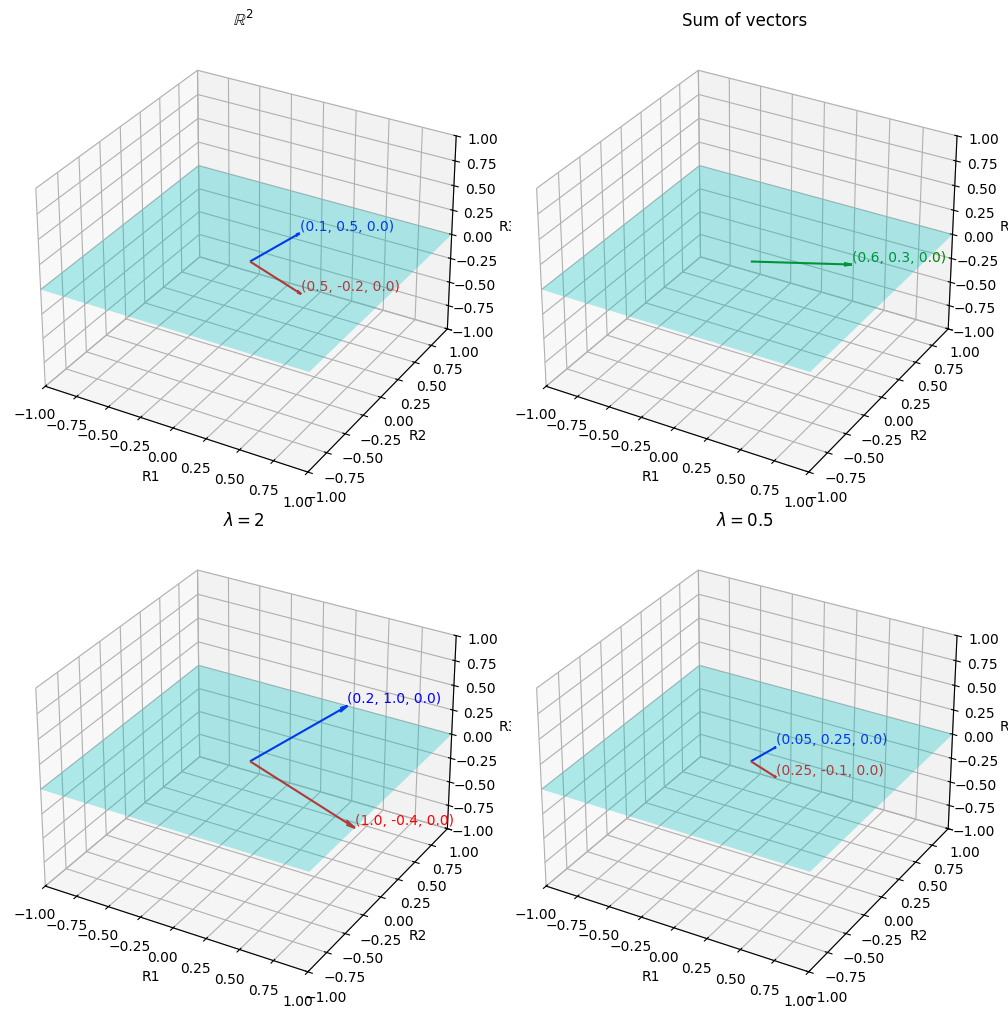

In [171]:
def config_3d(ax, title='$\mathbb{R}^3$'):
    ax.grid(True)
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)
    ax.set_zlim(-1,1)
    ax.set_title(title)
    ax.set_xlabel('R1')
    ax.set_ylabel('R2')
    ax.set_zlabel('R3')
    return ax
def plot_r2(ax):
    x = np.linspace(-1, 1, 10)
    y = np.linspace(-1, 1, 10)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)

    surf = ax.plot_surface(X, Y, Z, alpha=0.3, color='cyan')
    custom_patch = Patch(facecolor='cyan', edgecolor='cyan', label='$\mathbb{R}^2$')
    return surf, custom_patch

def plot_vector(ax, vector, color='b'):
    ax.quiver(0, 0, 0, vector[0], vector[1], vector[2],
        color=color, arrow_length_ratio=0.08)
    ax.text(vector[0], vector[1], vector[2],
        f'({vector[0]}, {vector[1]}, {vector[2]})',
        fontsize=10, ha='left', va='bottom', color=color)

vectors = np.array([
    [0.1, 0.5, 0],  
    [0.5, -0.2, 0]
])
colors = ["b", "r"]

fig = plt.figure(figsize=(10,10), constrained_layout=True)
axes = [fig.add_subplot(2, 2, i+1, projection='3d') for i in range(4)]

surf, custom_patch = plot_r2(axes[0])
for vector, color in zip(vectors, colors):
    plot_vector(axes[0], vector, color)
config_3d(axes[0], title='$\mathbb{R}^2$')

sum_vector = vectors.sum(axis=0)
surf, custom_patch = plot_r2(axes[1])
plot_vector(axes[1], sum_vector, "g")
config_3d(axes[1], title='Sum of vectors')


lam = 2
lambda_vector = lam * vectors
surf, custom_patch = plot_r2(axes[2])
for vector, color in zip(lambda_vector, colors):
    plot_vector(axes[2], vector, color)
config_3d(axes[2], title=f'$\lambda = {lam}$')


lam = 0.5
lambda_vector = lam * vectors
surf, custom_patch = plot_r2(axes[3])
for vector, color in zip(lambda_vector, colors):
    plot_vector(axes[3], vector, color)
config_3d(axes[3], title=f'$\lambda = {lam}$')

plt.show()